In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("Customer Churn.csv")

In [3]:
df.head

<bound method NDFrame.head of       Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0                 8          0                    38               0   
1                 0          0                    39               0   
2                10          0                    37               0   
3                10          0                    38               0   
4                 3          0                    38               0   
...             ...        ...                   ...             ...   
3145             21          0                    19               2   
3146             17          0                    17               1   
3147             13          0                    18               4   
3148              7          0                    11               2   
3149              8          1                    11               2   

      Seconds of Use  Frequency of use  Frequency of SMS  \
0               4370                71       

In [4]:
df.info

<bound method DataFrame.info of       Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0                 8          0                    38               0   
1                 0          0                    39               0   
2                10          0                    37               0   
3                10          0                    38               0   
4                 3          0                    38               0   
...             ...        ...                   ...             ...   
3145             21          0                    19               2   
3146             17          0                    17               1   
3147             13          0                    18               4   
3148              7          0                    11               2   
3149              8          1                    11               2   

      Seconds of Use  Frequency of use  Frequency of SMS  \
0               4370                71     

In [6]:
df.describe()

,Call Failure,Complains,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
count,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000,3150.000000
mean,7.627937,0.076508,32.541905,0.942857,4472.459683,69.460635,73.174921,23.509841,2.826032,1.077778,1.248254,30.998413,470.972916,0.157143
std,7.263886,0.265851,8.573482,1.521072,4197.908687,57.413308,112.237560,17.217337,0.892555,0.267864,0.432069,8.831095,517.015433,0.363993
min,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,15.000000,0.000000,0.000000
25%,1.000000,0.000000,30.000000,0.000000,1391.250000,27.000000,6.000000,10.000000,2.000000,1.000000,1.000000,25.000000,113.801250,0.000000
50%,6.000000,0.000000,35.000000,0.000000,2990.000000,54.000000,21.000000,21.000000,3.000000,1.000000,1.000000,30.000000,228.480000,0.000000
75%,12.000000,0.000000,38.000000,1.000000,6478.250000,95.000000,87.000000,34.000000,3.000000,1.000000,1.000000,30.000000,788.388750,0.000000
max,36.000000,1.000000,47.000000,10.000000,17090.000000,255.000000,522.000000,97.000000,5.000000,2.000000,2.000000,55.000000,2165.280000,1.000000


In [9]:
df.isnull().sum()

Call  Failure              0
Complains                  0
Subscription  Length       0
Charge  Amount             0
Seconds of Use             0
Frequency of use           0
Frequency of SMS           0
Distinct Called Numbers    0
Age Group                  0
Tariff Plan                0
Status                     0
Age                        0
Customer Value             0
Churn                      0
dtype: int64

In [22]:
"""
Customer Churn Prediction
XGBoost Classifier + 80/20 Train-Test Split + Full EDA
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
DATA_PATH = "Customer Churn.csv"
TARGET    = "Churn"
RANDOM_STATE = 42
TEST_SIZE = 0.20

PALETTE  = {"0": "#4C9BE8", "1": "#E8614C"}
COLORS   = ["#4C9BE8", "#E8614C"]
BG_COLOR = "#F7F9FC"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor":   BG_COLOR,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()       # clean whitespace in column names

features = [c for c in df.columns if c != TARGET]
X = df[features]
y = df[TARGET]

print(f"Dataset shape : {df.shape}")
print(f"Churn balance :\n{y.value_counts()}\n")

# ─────────────────────────────────────────────
# 2. EDA — Figure 1: Overview
# ─────────────────────────────────────────────
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle("EDA — Overview", fontsize=16, fontweight="bold", y=1.01)

# 2a. Target distribution
ax = axes[0, 0]
counts = y.value_counts()
bars = ax.bar(["Not Churned (0)", "Churned (1)"], counts.values,
              color=COLORS, edgecolor="white", linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    pct = val / len(y) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f"{val}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Target Distribution (Churn)")
ax.set_ylabel("Count")
ax.set_ylim(0, counts.max() * 1.2)

# 2b. Missing values heatmap
ax = axes[0, 1]
missing = df.isnull().sum()
if missing.sum() == 0:
    ax.text(0.5, 0.5, "✓  No Missing Values\nin the dataset",
            ha="center", va="center", fontsize=14,
            color="#2ECC71", fontweight="bold", transform=ax.transAxes)
    ax.set_title("Missing Values Check")
    ax.axis("off")
else:
    missing[missing > 0].plot(kind="bar", ax=ax, color="#E8614C")
    ax.set_title("Missing Values per Column")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

# 2c. Correlation heatmap
ax = axes[1, 0]
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            linewidths=0.4, annot=True, fmt=".2f",
            annot_kws={"size": 7}, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Heatmap")
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)

# 2d. Churn rate by Age Group
ax = axes[1, 1]
age_churn = df.groupby("Age Group")["Churn"].mean().reset_index()
bars = ax.bar(age_churn["Age Group"].astype(str), age_churn["Churn"],
              color="#4C9BE8", edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, age_churn["Churn"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_title("Churn Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Churn Rate")
ax.set_ylim(0, age_churn["Churn"].max() * 1.25)

fig1.tight_layout()
fig1.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.close(fig1)
print("Saved: eda_overview.png")

# ─────────────────────────────────────────────
# 3. EDA — Figure 2: Feature Distributions
# ─────────────────────────────────────────────
num_features = [f for f in features if df[f].nunique() > 10]
n_cols = 3
n_rows = (len(num_features) + n_cols - 1) // n_cols

fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
fig2.suptitle("EDA — Numerical Feature Distributions by Churn", fontsize=16, fontweight="bold")
axes2 = axes2.flatten()

for i, col in enumerate(num_features):
    ax = axes2[i]
    for churn_val, color in zip([0, 1], COLORS):
        data = df[df[TARGET] == churn_val][col]
        ax.hist(data, bins=25, alpha=0.65, color=color,
                label=f"Churn={churn_val}", edgecolor="white", linewidth=0.5)
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes2)):
    axes2[j].set_visible(False)

fig2.tight_layout()
fig2.savefig("eda_distributions.png", dpi=150, bbox_inches="tight")
plt.close(fig2)
print("Saved: eda_distributions.png")

# ─────────────────────────────────────────────
# 4. EDA — Figure 3: Boxplots + Categorical
# ─────────────────────────────────────────────
cat_features = [f for f in features if df[f].nunique() <= 10]
key_num = num_features[:6]   # top 6 numeric for boxplots

fig3, axes3 = plt.subplots(2, 3, figsize=(15, 10))
fig3.suptitle("EDA — Boxplots & Categorical Churn Rates", fontsize=16, fontweight="bold")
axes3 = axes3.flatten()

# Boxplots for numeric
for i, col in enumerate(key_num):
    ax = axes3[i]
    data_grp = [df[df[TARGET] == v][col].values for v in [0, 1]]
    bp = ax.boxplot(data_grp, patch_artist=True, widths=0.4,
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2))
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(["Not Churned", "Churned"])
    ax.set_title(f"{col} — by Churn")
    ax.set_ylabel(col)

fig3.tight_layout()
fig3.savefig("eda_boxplots.png", dpi=150, bbox_inches="tight")
plt.close(fig3)
print("Saved: eda_boxplots.png")

# ─────────────────────────────────────────────
# 5. EDA — Figure 4: Categorical churn rates
# ─────────────────────────────────────────────
if cat_features:
    n_cat = len(cat_features)
    n_c   = min(3, n_cat)
    n_r   = (n_cat + n_c - 1) // n_c
    fig4, axes4 = plt.subplots(n_r, n_c, figsize=(14, n_r * 4))
    fig4.suptitle("EDA — Categorical Features: Churn Rate", fontsize=16, fontweight="bold")
    axes4 = np.array(axes4).flatten()

    for i, col in enumerate(cat_features):
        ax = axes4[i]
        grp = df.groupby(col)[TARGET].mean().reset_index()
        bars = ax.bar(grp[col].astype(str), grp[TARGET],
                      color=COLORS[0], edgecolor="white", linewidth=1.5)
        for bar, val in zip(bars, grp[TARGET]):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.1%}", ha="center", va="bottom", fontsize=9)
        ax.set_title(f"Churn Rate by {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Churn Rate")
        ax.set_ylim(0, grp[TARGET].max() * 1.3)

    for j in range(i + 1, len(axes4)):
        axes4[j].set_visible(False)

    fig4.tight_layout()
    fig4.savefig("eda_categorical.png", dpi=150, bbox_inches="tight")
    plt.close(fig4)
    print("Saved: eda_categorical.png")

# ─────────────────────────────────────────────
# 6. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"\nTrain size : {X_train.shape[0]} ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Test  size : {X_test.shape[0]}  ({TEST_SIZE*100:.0f}%)")

# ─────────────────────────────────────────────
# 7. XGBoost MODEL
# ─────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 5,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale_pos_weight,
    use_label_encoder= False,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"\nROC-AUC : {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))

# ─────────────────────────────────────────────
# 8. MODEL RESULTS — Figure 5
# ─────────────────────────────────────────────
fig5 = plt.figure(figsize=(16, 10))
fig5.suptitle("XGBoost Model Results", fontsize=16, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig5, hspace=0.4, wspace=0.35)

# 8a. Confusion Matrix
ax_cm = fig5.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Churned", "Churned"])
disp.plot(ax=ax_cm, colorbar=False, cmap="Blues")
ax_cm.set_title("Confusion Matrix")
ax_cm.tick_params(axis="x", rotation=15)

# 8b. ROC Curve
ax_roc = fig5.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
ax_roc.plot(fpr, tpr, color=COLORS[0], lw=2, label=f"AUC = {roc_auc:.3f}")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
ax_roc.fill_between(fpr, tpr, alpha=0.1, color=COLORS[0])
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve")
ax_roc.legend(loc="lower right")

# 8c. Prediction probability distribution
ax_prob = fig5.add_subplot(gs[0, 2])
for churn_val, color, label in zip([0, 1], COLORS, ["Not Churned", "Churned"]):
    probs = y_pred_prob[y_test == churn_val]
    ax_prob.hist(probs, bins=25, alpha=0.65, color=color, label=label, edgecolor="white")
ax_prob.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Threshold = 0.5")
ax_prob.set_xlabel("Predicted Probability of Churn")
ax_prob.set_ylabel("Count")
ax_prob.set_title("Predicted Probability Distribution")
ax_prob.legend(fontsize=9)

# 8d. Feature Importance
ax_fi = fig5.add_subplot(gs[1, :])
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)
colors_fi = [COLORS[1] if v >= importances.quantile(0.75) else COLORS[0] for v in importances]
bars = ax_fi.barh(importances.index, importances.values,
                  color=colors_fi, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, importances.values):
    ax_fi.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
               f"{val:.3f}", va="center", fontsize=9)
ax_fi.set_xlabel("Feature Importance (Gain)")
ax_fi.set_title("XGBoost Feature Importances  [Red = Top Quartile]")
ax_fi.set_xlim(0, importances.max() * 1.15)

fig5.savefig("model_results.png", dpi=150, bbox_inches="tight")
plt.close(fig5)
print("Saved: model_results.png")

print("\n✅  All done. Check /mnt/user-data/outputs/ for all plots.")

Dataset shape : (3150, 14)
Churn balance :
Churn
0    2655
1     495
Name: count, dtype: int64

Saved: eda_overview.png
Saved: eda_distributions.png
Saved: eda_boxplots.png
Saved: eda_categorical.png

Train size : 2520 (80%)
Test  size : 630  (20%)

ROC-AUC : 0.9936

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.99      0.97      0.98       531
     Churned       0.85      0.95      0.90        99

    accuracy                           0.97       630
   macro avg       0.92      0.96      0.94       630
weighted avg       0.97      0.97      0.97       630

Saved: model_results.png

✅  All done. Check /mnt/user-data/outputs/ for all plots.


In [23]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

Status                     0.360432
Complains                  0.299780
Seconds of Use             0.049791
Subscription  Length       0.045510
Frequency of use           0.044455
Age Group                  0.037346
Customer Value             0.036358
Distinct Called Numbers    0.032181
Call  Failure              0.030541
Charge  Amount             0.022412
Age                        0.021668
Frequency of SMS           0.019525
Tariff Plan                0.000000
dtype: float32


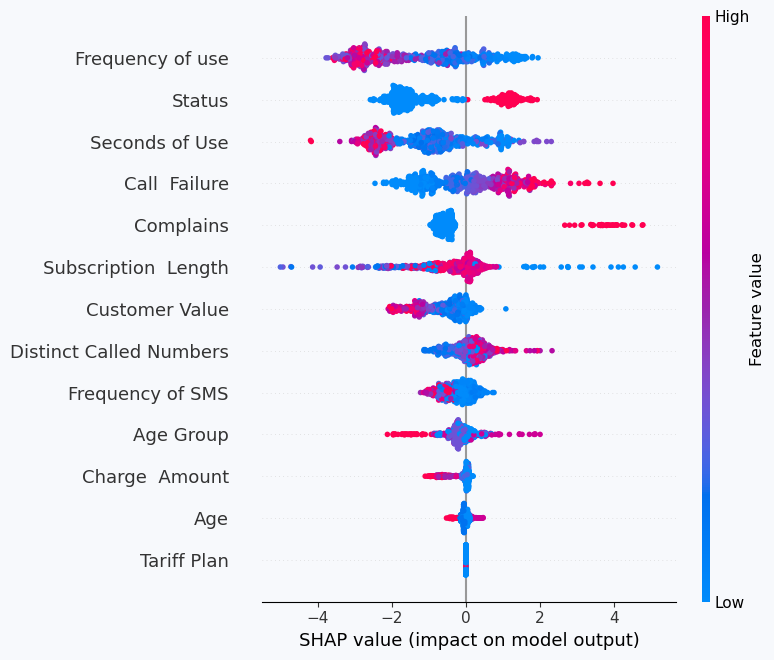

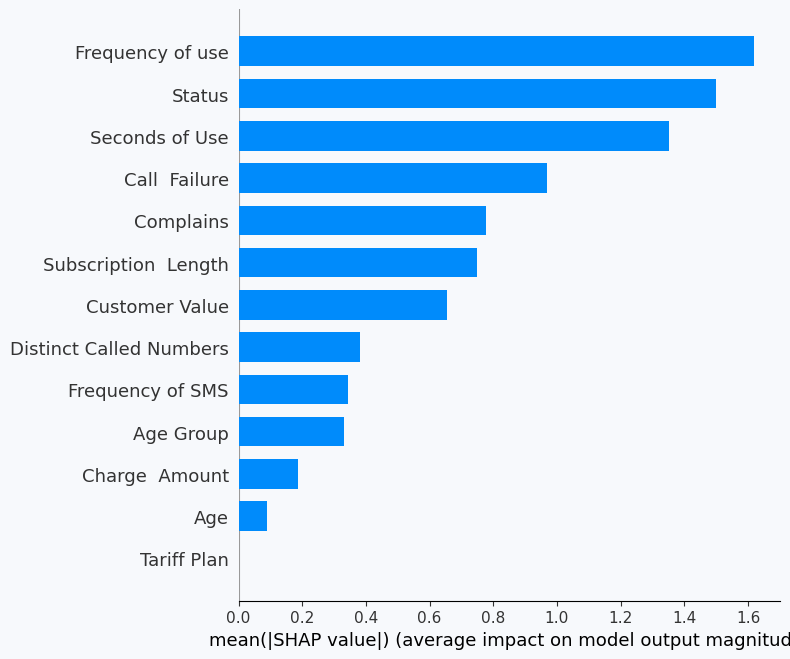

In [26]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary plot — shows impact of each feature
shap.summary_plot(shap_values, X_test)

# Bar plot — mean absolute SHAP value per feature
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [55]:
df_filter = df[(df["Complains"] == 1) & (df["Status"] == 2)]

In [39]:
print(df_filter.head(50))

      Call  Failure  Complains  Subscription  Length  Charge  Amount  \
22               23          1                    33               0   
172              24          1                    37               0   
272              28          1                    39               0   
372              25          1                    36               0   
422              21          1                    30               0   
472              27          1                    33               0   
572              23          1                    34               0   
672              25          1                    33               0   
772              21          1                    28               0   
822              25          1                    38               0   
872              29          1                    34               0   
1022             23          1                    33               0   
1322             23          1                    37            

In [56]:
df_filter["Churn"].describe()

count    158.000000
mean       0.892405
std        0.310853
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Churn, dtype: float64

In [37]:
df_filter["Status"].describe()

count    49.000000
mean      1.591837
std       0.496587
min       1.000000
25%       1.000000
50%       2.000000
75%       2.000000
max       2.000000
Name: Status, dtype: float64

In [57]:
shap.summary_plot(shap_values, X_test, show=False)
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.close()

In [58]:
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.savefig("shap_bar.png", dpi=150, bbox_inches="tight")
plt.close()

In [ ]:
Call Failure >= 17 Complains == 1 and Status == 2 was 100% Churn for 37 going down by call failure amount still very high
Disregarding call failure with Complains ==1 and Status == 2 still has a 90% churn rate